# 2. Matemáticas y diferenciación automática

**Objetivo.** Conectar vectores, matrices, derivadas y gradientes con el mecanismo que permite aprender a una red neuronal.

Una capa lineal calcula $y=Xw+b$. Aprender consiste en ajustar $w$ y $b$ para reducir una pérdida. El gradiente indica la variación local de esa pérdida respecto de cada parámetro.

In [1]:
import random
import torch
import matplotlib.pyplot as plt

SEMILLA = 42
random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
torch.set_printoptions(precision=3, sci_mode=False)
print(f"PyTorch {torch.__version__} · semilla {SEMILLA}")

PyTorch 2.14.0 · semilla 42


## Álgebra lineal de una predicción

Para un lote de $n$ observaciones con $d$ características, $X$ tiene forma $(n,d)$ y $w$ forma $(d,1)$. El producto matricial produce $n$ predicciones.

In [2]:
X = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
w = torch.tensor([[0.5], [-1.0]])
b = torch.tensor(2.0)
y = X @ w + b
print("X", X.shape, "w", w.shape, "y", y.shape, sep=" · ")
y

X · torch.Size([3, 2]) · w · torch.Size([2, 1]) · y · torch.Size([3, 1])


tensor([[ 0.500],
        [-0.500],
        [-1.500]])

## Derivada y gradiente

En una dimensión, la derivada es la pendiente local. Para $f(x)=x^2$, $f'(x)=2x$. En varias dimensiones, el gradiente reúne las derivadas parciales. Las diferencias finitas proporcionan una comprobación numérica.

In [3]:
def f(x):
    return x**2

x0, h = 3.0, 1e-4
aproximacion = (f(x0 + h) - f(x0 - h)) / (2 * h)
print("diferencias finitas:", aproximacion)
print("derivada exacta:", 2 * x0)

diferencias finitas: 6.000000000012662
derivada exacta: 6.0


## Diferenciación automática

Con `requires_grad=True`, PyTorch registra las operaciones en un grafo dinámico. `backward()` aplica la regla de la cadena desde el resultado hasta los parámetros.

In [4]:
x = torch.tensor([2.0, -1.0], requires_grad=True)
perdida = 3 * x[0]**2 + 2 * x[0] * x[1] + x[1]**2
perdida.backward()
analitico = torch.tensor([6*x[0] + 2*x[1], 2*x[0] + 2*x[1]])
print("pérdida:", perdida.item())
print("gradiente automático:", x.grad)
print("gradiente analítico:", analitico)

pérdida: 9.0
gradiente automático: tensor([10.,  2.])
gradiente analítico: tensor([10.,  2.])


/var/folders/4x/7rmf6phn3pg5bqn9yb3j2v780000gn/T/ipykernel_41097/2473033656.py:4: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:821.)
  analitico = torch.tensor([6*x[0] + 2*x[1], 2*x[0] + 2*x[1]])


## Descenso por el gradiente

Para minimizar $f(x)=(x-4)^2$, repetimos $x\leftarrow x-\eta f'(x)$. La tasa $\eta$ controla la longitud del paso.

x final: 3.9193


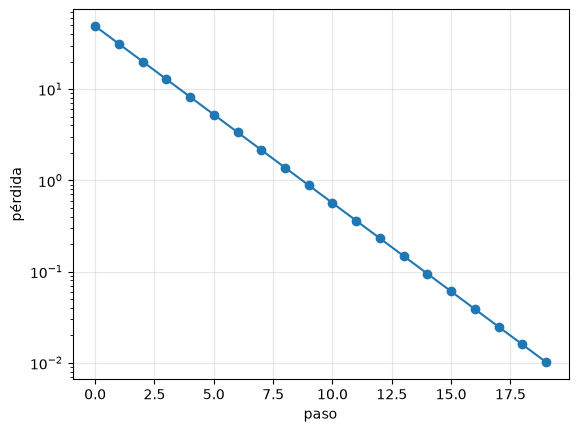

In [5]:
x = torch.tensor(-3.0, requires_grad=True)
historia = []
for paso in range(20):
    perdida = (x - 4) ** 2
    perdida.backward()
    with torch.no_grad():
        x -= 0.1 * x.grad
    x.grad.zero_()
    historia.append(perdida.item())

print("x final:", round(x.item(), 4))
plt.plot(historia, marker="o")
plt.xlabel("paso"); plt.ylabel("pérdida"); plt.yscale("log"); plt.grid(alpha=.3);

## Preguntas

1. ¿Qué ocurre con tasas de aprendizaje 0, 0.1, 1 y 1.1?
2. ¿Por qué actualizamos `x` dentro de `torch.no_grad()`?
3. ¿Por qué debemos poner el gradiente a cero después de cada paso?

**Idea clave:** la retropropagación calcula gradientes; el optimizador decide cómo usarlos.